In [ ]:
# import os
# import ctypes

# os.environ["CUDA_VISIBLE_DEVICES"] = ""  # " " for using CPU
# os.environ["DRJIT_LIBLLVM_PATH"] = "/home/aizi0357/environments/v0_sionna_public/lib/libLLVM-23.so"
# llvm_handle = ctypes.CDLL(os.environ["DRJIT_LIBLLVM_PATH"], mode=os.RTLD_NOW | os.RTLD_LOCAL | os.RTLD_DEEPBIND)

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("Visible GPUs:", gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

import sionna
import matplotlib.pyplot as plt
import numpy as np
import time

from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray

tf.get_logger().setLevel("ERROR")
tf.random.set_seed(1)

import matplotlib.pyplot as plt
import numpy as np
import time

# Import Sionna RT components
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray


I0000 00:00:1791189773.164738 1855015 cuda_fft.cc:470] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
I0000 00:00:1791189773.177713 1855015 cuda_dnn.cc:6964] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
I0000 00:00:1791189773.182105 1855015 cuda_blas.cc:1416] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791189773.190330 1855015 collection_registry.cc:88] Trying to register 2 metrics with the same name: /coordination_service/agent/enabled. The old value will be erased in order to register a new one. Please check if you link the metric more than once, or if the name is already used by other metrics.
W0000 00:00:1791189773.194776 1855015 computation_placer.cc:184] Computation placer creation function is already registered for this platform
W0000 00:00:179118

Visible GPUs: []


E0000 00:00:1791189775.112821 1855015 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1791189775.112907 1855015 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
I0000 00:00:1791189775.112917 1855015 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
I0000 00:00:1791189775.112923 1855015 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1791189775.112925 1855015 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: makalu69.rz.tu-ilmenau.de
I0000 00:00:1791189775.112934 1855015 cuda_diagnostics.cc:183] hostname: makalu69.rz.tu-ilmenau.de
I0000 00:00:1791189775.113045 1855015 cuda_diagnostics.cc:190] libcuda reported version is: 610.43.2
I0000 00:00:1791189775.113062 

In [2]:
is_small = False

dtype = tf.complex128
rdtype = tf.float64
nu = 12   # 12

if nu == 12:
      scene = load_scene(sionna.rt.scene.cylinder_12, dtype)
else:
     print("Invalid nu value")

tx_dist = 100.0  # TODO 100.0
num_points = 720  # 720, 360
pol = 'HH'   ## VV pol requires taller (infinite) cylinders

def get_circle_points(theta_arr, p1, p2):
    res = np.zeros((len(theta_arr), 3))
    res[:, 0] = p1[0] * np.cos(theta_arr) + p2[0] * np.sin(theta_arr)
    res[:, 1] = p1[1] * np.cos(theta_arr) + p2[1] * np.sin(theta_arr)
    res[:, 2] = p1[2] * np.cos(theta_arr) + p2[2] * np.sin(theta_arr)

    return res

num_edges: tf.Tensor(0, shape=(), dtype=int32)
num_wedges: 36


In [3]:
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization=pol[0],
                             dtype=dtype)

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization=pol[1],
                             dtype=dtype)

fc = 2e9  # TODO
lamda = 3e8 / fc

cylinder_radius = 12.8 * lamda
	
circle_radius = 9.0   # 60.0 * lamda  
if is_small:
    circle_radius *= 0.4
    tx_dist *= 0.4
    cylinder_radius *= 0.4

coef = (4 * np.pi * tx_dist)

source_point = np.array([tx_dist, 0.0, 0.0])
    
theta_arr = np.linspace(0.0, 2*np.pi, num_points, endpoint=False)
circle_p1 = np.array([1, 0, 0]) * circle_radius
circle_p2 = np.array([0, 1, 0])  * circle_radius
receive_points = get_circle_points(theta_arr, circle_p1, circle_p2)

scene.remove("tx")
for i in range(len(receive_points)):
    scene.remove(f"rx_{i}")


tx = Transmitter(name="tx", position=source_point, dtype=dtype) 
scene.add(tx)
for i in range(len(receive_points)):  # TODO:
    rx = Receiver(name=f"rx_{i}", position=receive_points[i], dtype=dtype)
    scene.add(rx)

scene.frequency = fc
scene.synthetic_array = True 


In [4]:
from sionna.rt.objects_geometry import ObjectsGeometry

obj_names = list(scene.objects.keys())

obj_geom = ObjectsGeometry(scene._solver_paths)
obj_geom.is_table_gfi = True
obj_geom.is_vertex_diffraction = True
obj_geom.is_double_diffraction = True
obj_geom.init_objects(obj_names, [None])

scene._solver_paths.vertex_diffraction.set_objects_geometry(obj_geom)
scene._solver_paths.double_diffraction.set_objects_geometry(obj_geom)

num vertices: 26


In [5]:
a1 = np.sqrt(2 * (1 - np.cos(2*np.pi/nu))) * (cylinder_radius / lamda)  # edge size in wavelengths
a2 = np.sqrt(2 * (1 - np.cos(2*np.pi/nu)))  # wrt radius
geom_deviation = cylinder_radius * (1 - np.cos(np.pi / nu)) / lamda  # in wavelengths
edge_size = a1 * lamda
e2_r = edge_size**2 / cylinder_radius
e2_rl = edge_size**2 / (cylinder_radius * lamda)
a1, a1*lamda, a2, geom_deviation, e2_r, e2_rl

(np.float64(6.62576755462453),
 np.float64(0.9938651331936794),
 np.float64(0.5176380902050414),
 np.float64(0.43614942349992564),
 np.float64(0.5144624494677553),
 np.float64(3.429749663118369))

In [6]:
def get_field_los_full(tx_pos, rx_poses):
    dist = np.linalg.norm(tx_pos - rx_poses, axis=1)
    field = 1.0 / dist / (4 * 3.141592653589793) * lamda 
    return field

field_los_full = get_field_los_full(source_point, receive_points)

paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = False,
                            diffraction = False,
                            vertex_diffraction = False)

a, tau = paths.cir()
path_amplitudes = a[0,:,0,0,0,:,0]
receiver_amplitudes_los = np.abs(np.sum(path_amplitudes, axis=1)) #/ lamda

los_line_idx = np.where(receiver_amplitudes_los <= 1e-6)[0][0], np.where(receiver_amplitudes_los <= 1e-6)[0][-1]
field_los_full = np.where(receiver_amplitudes_los <= 0.0, field_los_full, receiver_amplitudes_los) + 1e-6
if pol == 'VV':
    field_los_full = -field_los_full
    
from scipy.constants import c as speed_of_light
dist = np.linalg.norm(source_point - receive_points, axis=1)
field_los_full2 = field_los_full * np.exp(-1j * 2 * np.pi * fc * dist/speed_of_light)

los_line_idx

(np.int64(334), np.int64(386))

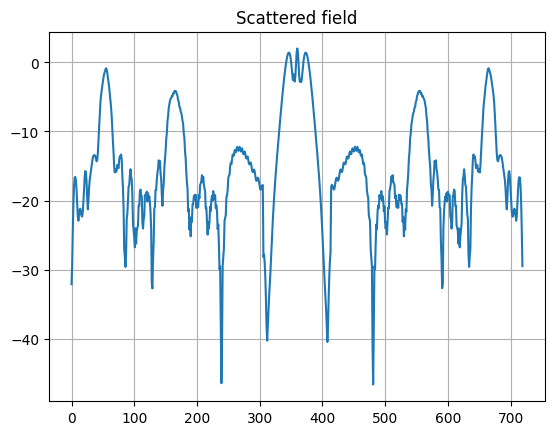

In [7]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = False,)

paths.normalize_delays = False
a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1) + field_los_full2
receiver_amplitudes_ = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_))
plt.title('Scattered field')
plt.grid()

/home/aizi0357/projects/sionna_reflectivity_public/sionna/rt/double_diffraction.py:3035: RuntimeWarning: divide by zero encountered in divide
  spreading_factor = np.sqrt(r1) / (np.sqrt(l * r2) * np.sqrt(r1 + l + r2))


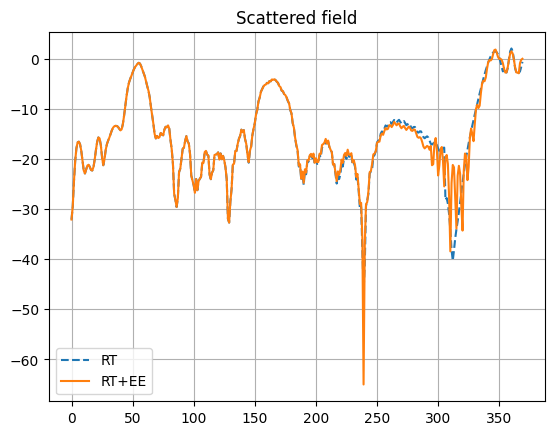

In [8]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = True,)

paths.normalize_delays = False

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1) + field_los_full2
receiver_amplitudes = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_[:num_points//2 + 10]), label='RT', linestyle='--')
plt.plot(20*np.log10(coef*receiver_amplitudes[:num_points//2 + 10]), label='RT+EE')
plt.title('Scattered field')
plt.grid()
plt.legend()

In [9]:
# Analytical curve (plane-wave incidence)

from sionna.rt.analytical_equations import cylinder_te_inc_scat_total, cylinder_tm_inc_scat_total
	
if pol == 'HH':
	u_inc, an_scattering, an_total = cylinder_te_inc_scat_total(theta_arr, cylinder_radius, circle_radius, 2*np.pi / lamda, terms=512)
elif pol == 'VV':
	u_inc, an_scattering, an_total = cylinder_tm_inc_scat_total(theta_arr, cylinder_radius, circle_radius, 2*np.pi / lamda, terms=512)

In [10]:
# los_line_idx
back_idxs = np.concatenate((np.arange(los_line_idx[0]), np.arange(los_line_idx[1], num_points)))
forw_idxs = np.arange(los_line_idx[0], los_line_idx[1])

def rmse(x, y, idxs):
	return np.sqrt(np.mean((x[idxs]-y[idxs])**2))


rmse_ee = rmse(20*np.log10(np.abs(an_scattering)), 20*np.log10(coef*receiver_amplitudes), back_idxs)
rmse_ee

np.float64(8.5693588361883)

Text(0, 0.5, '|E_sc| (dB)')

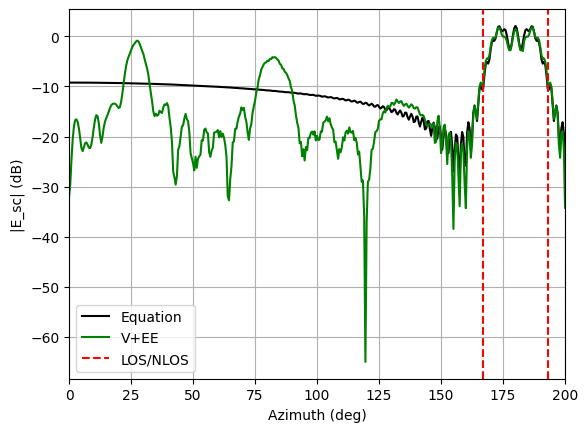

In [11]:
plt.plot(57.3*theta_arr, 20*np.log10(np.abs(an_scattering)), 'k', label='Equation')
plt.plot(57.3*theta_arr, 20*np.log10(coef*receiver_amplitudes), 'g', label='V+EE')
plt.axvline(x=57.3*theta_arr[los_line_idx[0]], color='r', linestyle='--', label='LOS/NLOS')
plt.axvline(x=57.3*theta_arr[los_line_idx[1]], color='r', linestyle='--')
plt.grid()
plt.xlim(0, 200)
plt.legend()
plt.xlabel("Azimuth (deg)")
plt.ylabel("|E_sc| (dB)")

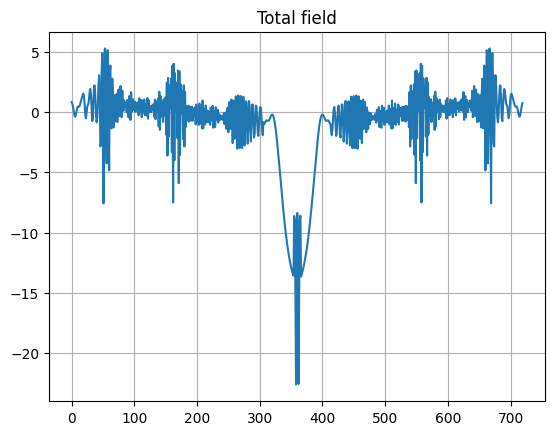

In [12]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = False,)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1)
receiver_amplitudes_ = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_))
plt.title('Total field')
plt.grid()

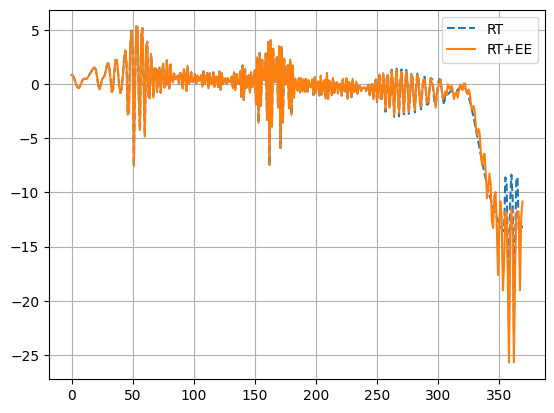

In [13]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = True,)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1)
receiver_amplitudes = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_[:num_points//2+10]), label='RT', linestyle='--')
plt.plot(20*np.log10(coef*receiver_amplitudes[:num_points//2+10]), label='RT+EE')
# plt.title('Total field')
plt.grid()
plt.legend()

In [14]:
rmse_ee = rmse(20*np.log10(np.abs(an_total)), 20*np.log10(coef*receiver_amplitudes), forw_idxs)
rmse_ee

np.float64(1.064505841248131)

Text(0, 0.5, '|E_tot| (dB)')

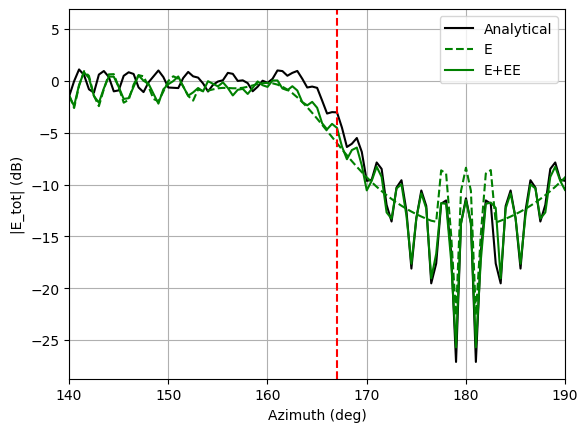

In [15]:
plt.plot(57.3*theta_arr, 20*np.log10(np.abs(an_total)), 'k', label='Analytical')
plt.plot(57.3*theta_arr, 20*np.log10(coef*receiver_amplitudes_), 'g--', label='E')
plt.plot(57.3*theta_arr, 20*np.log10(coef*receiver_amplitudes), 'g', label='E+EE')
	
plt.axvline(x=theta_arr[los_line_idx[0]]*57.3, color='r', linestyle='--')
plt.grid()
plt.xlim(140, 190)
plt.legend()
plt.xlabel("Azimuth (deg)")
plt.ylabel("|E_tot| (dB)")